# 01 — Preparação de Dados OCDE para o Projeto Market Twin

Este notebook realiza a etapa de **preparação, validação e exportação da base OCDE** usada no projeto. Ele não tem como objetivo principal aplicar modelos de aprendizado de máquina; sua função é construir uma base analítica confiável para que, depois, outros notebooks possam fazer modelagem, comparação entre países ou integração com outras fontes, como Banco Mundial.

A base original possui dados por país, setor e ano. Como o projeto trabalha com o setor de software de forma agregada, este notebook filtra e soma os setores `J62` e `J63`, trata problemas de cobertura, identifica valores suspeitos, imputa ausências de forma controlada e calcula indicadores derivados.

O fluxo geral é:

```text
dados_ocde_software.csv
        ↓
seleção dos setores J62 e J63
        ↓
agregação por país e ano
        ↓
validação de cobertura e remoção de países inviáveis
        ↓
tratamento de zeros suspeitos e valores ausentes
        ↓
cálculo de PROD e TAMANHO_MEDIO
        ↓
identificação de outliers de produtividade
        ↓
normalização dos indicadores
        ↓
exportação das bases corrigidas
```

Ao final, são gerados dois arquivos:

`dados_ocde_preparado_corrigido.csv`  
Base em valores reais/originais, recomendada para interpretação econômica, integração com outras bases e análises descritivas.

`dados_ocde_normalizado_corrigido.csv`  
Base com indicadores padronizados, útil para algoritmos de distância, clustering e análises de aprendizado de máquina.

A ideia principal é separar claramente duas responsabilidades: este notebook **prepara os dados**; o notebook seguinte **analisa os dados preparados**.


---

## 0. Bibliotecas e configuração geral

Nesta etapa são carregadas as bibliotecas usadas no notebook e são definidos alguns parâmetros centrais da preparação.

As bibliotecas `pandas` e `numpy` são usadas para manipulação dos dados. `matplotlib` e `seaborn` são mantidas para inspeções visuais simples. O `StandardScaler`, do `scikit-learn`, é usado ao final para gerar uma versão normalizada dos indicadores.

Também são definidos:

`SETORES_ALVO = ["J62", "J63"]`  
Indica quais setores da OCDE serão usados para representar o mercado de software/informação.

`COLUNAS_BASE = ["ENTR", "TUTT", "EMPE"]`  
São as variáveis originais da base que serão limpas e imputadas.

`INDICADORES = ["ENTR", "TUTT", "EMPE", "PROD", "TAMANHO_MEDIO"]`  
São as variáveis finais usadas na análise.

`COBERTURA_MINIMA = 60.0`  
Define o percentual mínimo de cobertura temporal para manter um país na base.

`TUTT_ZERO_AS_MISSING = True`  
Define que valores de `TUTT = 0` serão tratados como ausência provável quando houver empresas ou empregados registrados. Essa decisão evita que valores possivelmente ausentes sejam interpretados como produtividade real igual a zero.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

SETORES_ALVO = ["J62", "J63"]

COLUNAS_BASE = ["ENTR", "TUTT", "EMPE"]
INDICADORES = ["ENTR", "TUTT", "EMPE", "PROD", "TAMANHO_MEDIO"]

COBERTURA_MINIMA = 60.0
TUTT_ZERO_AS_MISSING = True


---

## 1. Carregamento da base original

A primeira etapa prática é carregar a base original extraída da OCDE. Essa base ainda não está pronta para modelagem, pois contém dados separados por país, setor e ano.

O notebook procura automaticamente por nomes comuns de arquivo, como:

```text
dados_ocde_software.csv
dados_ocde_software(1).csv
```

Essa busca flexível foi incluída porque, em ambientes como o Google Colab, arquivos reenviados costumam receber sufixos como `(1)`, `(2)` etc.

Depois do carregamento, o notebook exibe informações básicas da base: dimensões, quantidade de países, intervalo temporal, setores disponíveis e primeiras linhas. Essa inspeção inicial serve para confirmar que a base foi lida corretamente antes de qualquer transformação.


In [2]:
def localizar_arquivo(candidatos, pasta="."):
    pasta = Path(pasta)
    for nome in candidatos:
        caminho = pasta / nome
        if caminho.exists():
            return caminho

    # Busca flexível: aceita variações como dados_ocde_software(1).csv
    csvs = sorted(pasta.glob("*.csv"))
    for csv in csvs:
        nome_limpo = csv.name.lower().replace(" ", "")
        if "dados_ocde_software" in nome_limpo:
            return csv

    raise FileNotFoundError(
        "Não encontrei a base original. Coloque o arquivo dados_ocde_software.csv "
        "na mesma pasta do notebook."
    )

ARQUIVO_ORIGINAL = localizar_arquivo([
    "dados_ocde_software.csv",
    "dados_ocde_software(1).csv",
    "dados_ocde_software (1).csv",
])

print(f"Arquivo carregado: {ARQUIVO_ORIGINAL}")

df_raw = pd.read_csv(ARQUIVO_ORIGINAL)

print(f"Shape original: {df_raw.shape}")
print(f"Colunas: {df_raw.columns.tolist()}")
print(f"Países: {df_raw['Pais'].nunique()}")
print(f"Setores: {sorted(df_raw['Setor'].dropna().unique())}")
print(f"Anos: {int(df_raw['Ano'].min())}–{int(df_raw['Ano'].max())}")

display(df_raw.head())

Arquivo carregado: dados_ocde_software(1).csv
Shape original: (1020, 6)
Colunas: ['Pais', 'Setor', 'Ano', 'EMPE', 'ENTR', 'TUTT']
Países: 43
Setores: ['J62', 'J63']
Anos: 2010–2022


,Pais,Setor,Ano,EMPE,ENTR,TUTT
0,ALB,J62,2019,4549.0,1167.0,15646.872070
1,ALB,J62,2020,4771.0,1442.0,18850.169922
2,ALB,J63,2019,912.0,445.0,2226.481201
3,ALB,J63,2020,1654.0,424.0,2958.102783
4,ALB,J63,2021,1798.0,291.0,4411.009277


**Como interpretar esta saída**

A saída desta célula confirma se a base original foi carregada corretamente. A contagem de países, anos e setores ajuda a verificar se estamos trabalhando com a extração esperada. Se algum desses números estiver muito diferente do previsto, o problema provavelmente está no arquivo carregado, não nas etapas de preparação.

Neste ponto, ainda não há limpeza substantiva. A base ainda pode conter duplicatas, setores fora do escopo, valores ausentes e zeros suspeitos.


---

## 2. Preparação dos dados

A preparação dos dados transforma a base original em uma tabela adequada para análise comparativa entre países.

A base original contém observações por país, setor e ano. Porém, para o projeto, o interesse é observar o setor de software/informação de forma agregada. Por isso, os setores `J62` e `J63` são filtrados e somados por país e ano.

Nesta etapa também ocorre uma decisão metodológica importante: tratar `TUTT = 0` como valor suspeito quando existem empresas (`ENTR`) ou empregados (`EMPE`) registrados. A razão é simples: se um país possui empresas e pessoas empregadas no setor, um valor econômico total exatamente zero provavelmente representa ausência, supressão ou problema de reporte, e não produção real nula.

Essa decisão evita um erro grave: deixar `TUTT = 0` virar automaticamente `PROD = 0`. Como produtividade é calculada por `TUTT / EMPE`, um zero artificial em `TUTT` derrubaria a produtividade daquele país/ano e poderia distorcer clustering, distâncias e comparações futuras.

A preparação desta seção realiza quatro tarefas principais:

1. padroniza tipos e nomes;
2. filtra os setores de interesse;
3. remove duplicatas exatas;
4. agrega `J62 + J63` por país e ano.


In [3]:
df = df_raw.copy()

# Padronização de tipos
df["Pais"] = df["Pais"].astype(str).str.strip()
df["Setor"] = df["Setor"].astype(str).str.strip()

for col in ["Ano", "ENTR", "TUTT", "EMPE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtrar setores de software usados no projeto
df = df[df["Setor"].isin(SETORES_ALVO)].copy()

# Remover duplicatas exatas por país, setor e ano
n_antes = len(df)
df = df.drop_duplicates(subset=["Pais", "Setor", "Ano"])
print(f"Duplicatas removidas: {n_antes - len(df)}")

# Agregar J62 + J63 por país e ano.
# min_count=1 preserva NaN quando todos os componentes são ausentes.
df_agregado = (
    df.groupby(["Pais", "Ano"], as_index=False)[COLUNAS_BASE]
    .sum(min_count=1)
    .sort_values(["Pais", "Ano"])
    .reset_index(drop=True)
)

# Flags antes de alterar TUTT
flag_tutt_zero = (
    df_agregado["TUTT"].eq(0)
    & (
        df_agregado["ENTR"].fillna(0).gt(0)
        | df_agregado["EMPE"].fillna(0).gt(0)
    )
)

flag_tutt_nan_original = df_agregado["TUTT"].isna()

df_agregado["Flag_TUTT_Zero_Suspeito"] = flag_tutt_zero.astype(int)
df_agregado["Flag_TUTT_Ausente_Ou_Imputado"] = (
    flag_tutt_zero | flag_tutt_nan_original
).astype(int)

if TUTT_ZERO_AS_MISSING:
    df_agregado.loc[flag_tutt_zero, "TUTT"] = np.nan

print(f"Shape após agregação J62+J63: {df_agregado.shape}")
print(f"Países após agregação: {df_agregado['Pais'].nunique()}")

print("\nCasos de TUTT = 0 suspeito encontrados na base agregada:")
display(
    df_agregado.loc[df_agregado["Flag_TUTT_Zero_Suspeito"].eq(1),
                    ["Pais", "Ano", "ENTR", "TUTT", "EMPE", "Flag_TUTT_Zero_Suspeito"]]
)

Duplicatas removidas: 0
Shape após agregação J62+J63: (511, 7)
Países após agregação: 43

Casos de TUTT = 0 suspeito encontrados na base agregada:


,Pais,Ano,ENTR,TUTT,EMPE,Flag_TUTT_Zero_Suspeito
175,FIN,2013,6424.0,NaN,NaN,1
319,LUX,2010,1372.0,NaN,NaN,1
329,LUX,2020,2267.0,NaN,NaN,1
353,MKD,2019,1311.0,NaN,9655.0,1
357,MLT,2010,696.0,NaN,1617.0,1
359,MLT,2012,698.0,NaN,2410.0,1
360,MLT,2013,621.0,NaN,2634.0,1


**O que esta etapa entrega**

Ao final desta célula, os dados deixam de estar separados por setor e passam a estar organizados por país e ano. Isso significa que cada linha passa a representar o setor de software/informação agregado de um país em determinado ano.

Também são criadas flags para rastrear casos de `TUTT` problemático. Essa rastreabilidade é importante porque permite saber, posteriormente, quais observações foram tratadas e evita que o processo de limpeza fique invisível.


### 2.1 Filtro de cobertura temporal

Depois da agregação, é necessário verificar se cada país possui dados suficientes ao longo do tempo. Países com pouquíssimos anos disponíveis podem prejudicar a análise, porque uma trajetória curta ou cheia de lacunas não é comparável de forma justa com países que possuem série quase completa.

O critério adotado foi manter países com pelo menos **60% de cobertura em `ENTR`**. A variável `ENTR` foi usada como referência porque representa o número de empresas e tende a indicar se o país possui presença minimamente consistente na base.

Esse filtro não exige uma série perfeita. Países com algumas ausências ainda podem permanecer, desde que tenham cobertura suficiente para permitir imputação e análise temporal. O objetivo é remover apenas casos em que a informação disponível é fraca demais para sustentar comparações.

Além disso, registros com `ENTR <= 0` ou `EMPE <= 0` são removidos, pois não há interpretação econômica adequada para número de empresas ou empregados menor ou igual a zero no contexto desta análise.


Linhas removidas por ENTR/EMPE <= 0: 0
Limite de cobertura: 60.0%
Países removidos por baixa cobertura (5): ['COL', 'KOR', 'ALB', 'USA', 'SRB']
Países mantidos: 38


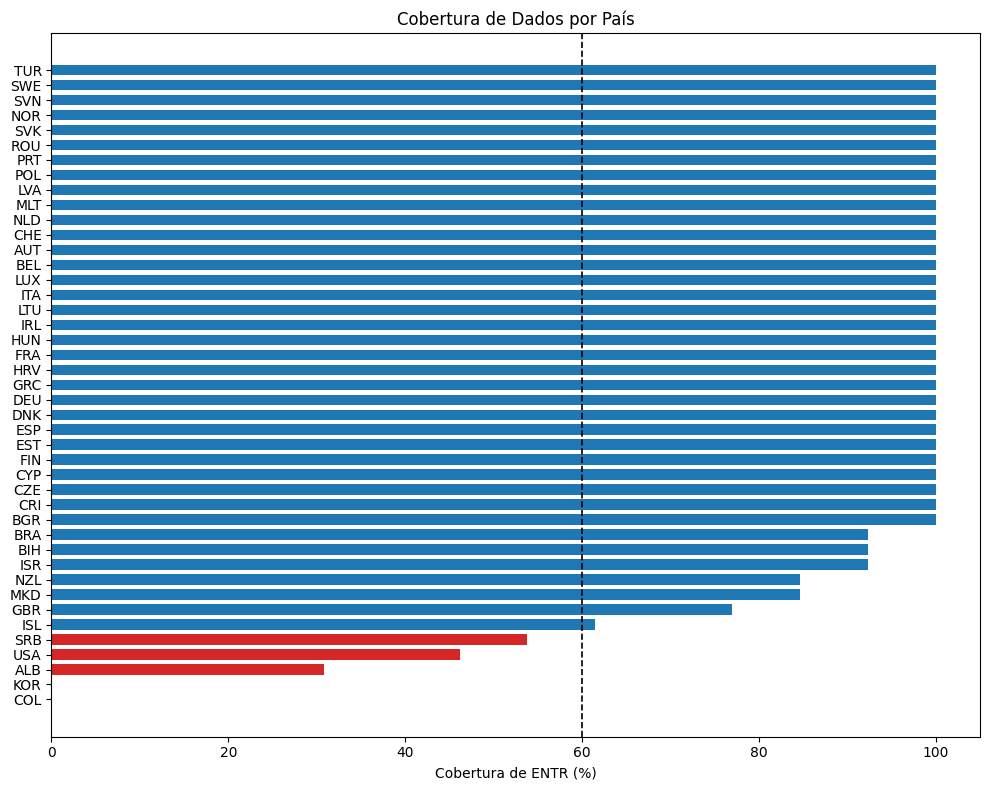

In [4]:
df = df_agregado.copy()

# Remover valores impossíveis em ENTR e EMPE.
# Como não há interpretação econômica razoável para número de empresas ou empregados <= 0,
# esses registros são excluídos.
n_antes = len(df)
df = df[~((df["ENTR"] <= 0) | (df["EMPE"] <= 0))].copy()
print(f"Linhas removidas por ENTR/EMPE <= 0: {n_antes - len(df)}")

n_anos_total = df["Ano"].nunique()

cobertura = (
    df.groupby("Pais")["ENTR"]
    .apply(lambda s: s.notna().sum() / n_anos_total)
    .mul(100)
    .round(1)
    .sort_values()
    .rename("Cobertura_ENTR_Pct")
    .reset_index()
)

paises_removidos_cobertura = cobertura.loc[
    cobertura["Cobertura_ENTR_Pct"] < COBERTURA_MINIMA, "Pais"
].tolist()

paises_mantidos = cobertura.loc[
    cobertura["Cobertura_ENTR_Pct"] >= COBERTURA_MINIMA, "Pais"
].tolist()

print(f"Limite de cobertura: {COBERTURA_MINIMA:.1f}%")
print(f"Países removidos por baixa cobertura ({len(paises_removidos_cobertura)}): {paises_removidos_cobertura}")
print(f"Países mantidos: {len(paises_mantidos)}")

fig, ax = plt.subplots(figsize=(10, 8))
cores = [
    "#d62728" if c < COBERTURA_MINIMA else "#1f77b4"
    for c in cobertura["Cobertura_ENTR_Pct"]
]
ax.barh(cobertura["Pais"], cobertura["Cobertura_ENTR_Pct"], color=cores, height=0.7)
ax.axvline(COBERTURA_MINIMA, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Cobertura de ENTR (%)")
ax.set_title("Cobertura de Dados por País")
plt.tight_layout()
plt.show()

df = df[df["Pais"].isin(paises_mantidos)].copy()

**Por que esse filtro é necessário**

Modelos de trajetória dependem de uma sequência temporal minimamente confiável. Se um país aparece em poucos anos, ele pode parecer artificialmente parecido ou diferente de outros países apenas por falta de dados.

O filtro de cobertura reduz esse risco. Ele não busca deixar a base perfeita, mas sim remover casos com informação insuficiente para comparação temporal.


### 2.2 Remoção de países com indicadores críticos totalmente ausentes

Mesmo que um país tenha boa cobertura em `ENTR`, ele pode ter problemas graves em outras variáveis. Por exemplo, se `TUTT` estiver totalmente ausente, não será possível calcular produtividade. Se `EMPE` estiver totalmente ausente, também não será possível calcular nem produtividade nem tamanho médio das empresas.

Por isso, esta etapa verifica se algum país possui indicadores críticos completamente ausentes. Os indicadores avaliados são:

`TUTT`  
Necessário para calcular produtividade.

`EMPE`  
Necessário para calcular produtividade e tamanho médio das empresas.

Países com ausência total nesses campos são removidos. Essa decisão é preferível a tentar imputar uma série inteira sem nenhuma observação real, o que seria uma intervenção forte demais e pouco defensável metodologicamente.


In [5]:
COLUNAS_CRITICAS = ["TUTT", "EMPE"]

paises_remover_criticos = set()

for col in COLUNAS_CRITICAS:
    totalmente_ausentes = df.groupby("Pais")[col].apply(lambda x: x.isna().all())
    paises_col = totalmente_ausentes[totalmente_ausentes].index.tolist()
    if paises_col:
        print(f"{col} totalmente ausente em: {paises_col}")
    paises_remover_criticos.update(paises_col)

print(f"\nPaíses removidos por indicador crítico ausente: {sorted(paises_remover_criticos)}")

n_antes = len(df)
df = df[~df["Pais"].isin(paises_remover_criticos)].copy()
print(f"Linhas removidas: {n_antes - len(df)}")
print(f"Shape após remoção: {df.shape}")
print(f"Países restantes: {df['Pais'].nunique()}")

TUTT totalmente ausente em: ['ISR']
EMPE totalmente ausente em: ['CHE', 'NZL']

Países removidos por indicador crítico ausente: ['CHE', 'ISR', 'NZL']
Linhas removidas: 36
Shape após remoção: (444, 7)
Países restantes: 35


**Por que não imputar países com indicador totalmente ausente?**

Quando uma variável tem poucas lacunas, a imputação pode ser razoável. Mas quando uma variável inteira está ausente para um país, a imputação deixa de ser uma correção pontual e passa a criar uma série completa sem base observada.

Por isso, esses países são removidos. Essa decisão torna a base menor, mas aumenta a confiabilidade dos indicadores finais.


### 2.3 Imputação das variáveis base

A imputação é aplicada somente às variáveis originais da base:

```text
ENTR
TUTT
EMPE
```

As variáveis derivadas `PROD` e `TAMANHO_MEDIO` não são imputadas diretamente. Elas são recalculadas depois. Isso preserva as identidades econômicas:

```text
PROD = TUTT / EMPE
TAMANHO_MEDIO = EMPE / ENTR
```

Essa escolha é importante. Se `PROD` fosse imputada diretamente, ela poderia deixar de bater com `TUTT / EMPE`. Ao imputar apenas as variáveis base e recalcular os indicadores derivados, o notebook mantém consistência matemática.

A imputação segue uma sequência em camadas:

1. **Interpolação linear por país**, limitada a lacunas de até 2 anos. Essa etapa usa a trajetória temporal do próprio país para preencher pequenas ausências.
2. **Média móvel centrada de 3 anos**, útil para suavizar lacunas pontuais usando anos vizinhos.
3. **Mediana histórica do próprio país**, usada quando ainda restam ausências após as etapas temporais.
4. **Mediana global**, usada apenas como fallback extremo para garantir que nenhuma variável base permaneça ausente.

Essa sequência tenta priorizar informações mais próximas e específicas do país antes de recorrer a uma regra global.


In [6]:
df = df.sort_values(["Pais", "Ano"]).copy()

nan_antes = df[COLUNAS_BASE].isna().sum()

# 1. Interpolação linear limitada
df[COLUNAS_BASE] = (
    df.groupby("Pais")[COLUNAS_BASE]
    .transform(lambda s: s.interpolate(method="linear", limit=2, limit_direction="both"))
)

nan_pos_interpolacao = df[COLUNAS_BASE].isna().sum()

# 2. Média móvel centrada
for col in COLUNAS_BASE:
    df[col] = df.groupby("Pais")[col].transform(
        lambda x: x.fillna(x.rolling(window=3, min_periods=1, center=True).mean())
    )

nan_pos_rolling = df[COLUNAS_BASE].isna().sum()

# 3. Mediana histórica do país
for col in COLUNAS_BASE:
    df[col] = df.groupby("Pais")[col].transform(lambda x: x.fillna(x.median()))

nan_pos_mediana_pais = df[COLUNAS_BASE].isna().sum()

# 4. Fallback global
for col in COLUNAS_BASE:
    df[col] = df[col].fillna(df[col].median())

nan_final_base = df[COLUNAS_BASE].isna().sum()

resumo_imputacao = pd.DataFrame({
    "NaN antes": nan_antes,
    "Após interpolação": nan_pos_interpolacao,
    "Após média móvel": nan_pos_rolling,
    "Após mediana do país": nan_pos_mediana_pais,
    "Final": nan_final_base,
})

display(resumo_imputacao)

# Recalcular derivadas após a imputação final das variáveis base
df["PROD"] = df["TUTT"] / df["EMPE"]
df["TAMANHO_MEDIO"] = df["EMPE"] / df["ENTR"]

print("NaN finais nas variáveis usadas no modelo:")
display(df[INDICADORES].isna().sum().to_frame("NaN"))

print("\nRegistros com TUTT originalmente ausente ou suspeito e posteriormente imputado:")
display(
    df.loc[df["Flag_TUTT_Ausente_Ou_Imputado"].eq(1),
           ["Pais", "Ano", "ENTR", "TUTT", "EMPE", "PROD", "Flag_TUTT_Zero_Suspeito", "Flag_TUTT_Ausente_Ou_Imputado"]]
    .head(20)
)

,NaN antes,Após interpolação,Após média móvel,Após mediana do país,Final
ENTR,1,0,0,0,0
TUTT,9,1,0,0,0
EMPE,8,1,0,0,0


NaN finais nas variáveis usadas no modelo:


,NaN
ENTR,0
TUTT,0
EMPE,0
PROD,0
TAMANHO_MEDIO,0



Registros com TUTT originalmente ausente ou suspeito e posteriormente imputado:


,Pais,Ano,ENTR,TUTT,EMPE,PROD,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado
175,FIN,2013,6424.0,7986.200195,48958.0,0.163123,1,1
319,LUX,2010,1372.0,2006.500046,8350.0,0.240299,1,1
329,LUX,2020,2267.0,2802.000000,11384.0,0.246135,1,1
330,LUX,2021,2626.0,2802.000000,11384.0,0.246135,0,1
331,LUX,2022,2650.0,2802.000000,11384.0,0.246135,0,1
353,MKD,2019,1311.0,17529.706909,9655.0,1.815609,1,1
357,MLT,2010,696.0,410.799988,1617.0,0.254051,1,1
359,MLT,2012,698.0,490.266663,2410.0,0.203430,1,1
360,MLT,2013,621.0,569.733337,2634.0,0.216300,1,1


**Resultado esperado da imputação**

Depois desta célula, as variáveis base devem estar completas. A partir delas, `PROD` e `TAMANHO_MEDIO` são recalculadas de forma consistente.

As flags mantidas na base não significam que ainda há dados ausentes. Elas indicam que determinado registro passou por tratamento. Isso é útil para auditoria e transparência metodológica.


### 2.4 Identificação de outliers de produtividade

Depois da imputação e do recálculo dos indicadores derivados, o notebook identifica países com produtividade muito fora do padrão.

A produtividade (`PROD`) é uma variável sensível: países pequenos, diferenças metodológicas, composição setorial específica ou valores muito altos de `TUTT` em relação a `EMPE` podem gerar números extremamente elevados. Esses casos não devem ser ignorados, mas também não devem dominar a análise dos demais países.

O critério usado é o **IQR** no ano mais recente disponível de cada país. O IQR, ou intervalo interquartil, permite detectar valores muito acima da distribuição típica da amostra.

Os países identificados como outliers não são removidos da base. Eles recebem uma flag:

```text
Flag_Outlier_Prod = 1
```

Essa marcação é útil porque análises posteriores podem tratar esses países de forma especial. Por exemplo, no notebook de Market Twin, eles podem ser separados como “perfil atípico de produtividade aparente”, evitando que sejam interpretados automaticamente como mercados mais maduros.


In [7]:
df_snapshot = (
    df.dropna(subset=["ENTR", "TUTT", "EMPE", "PROD"])
    .sort_values("Ano")
    .groupby("Pais", as_index=False)
    .tail(1)
)

q1 = df_snapshot["PROD"].quantile(0.25)
q3 = df_snapshot["PROD"].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

paises_outlier_prod = (
    df_snapshot.loc[df_snapshot["PROD"] > lim_sup, "Pais"]
    .sort_values()
    .tolist()
)

df["Flag_Outlier_Prod"] = df["Pais"].isin(paises_outlier_prod).astype(int)

print(f"Limite superior IQR para PROD: {lim_sup:.4f}")
print(f"Países marcados como outliers de produtividade: {paises_outlier_prod}")

display(
    df_snapshot.loc[df_snapshot["Pais"].isin(paises_outlier_prod),
                    ["Pais", "Ano", "PROD", "TUTT", "EMPE", "ENTR"]]
    .sort_values("PROD", ascending=False)
)

# Organização final das colunas
df = df[
    [
        "Pais", "Ano",
        "ENTR", "TUTT", "EMPE",
        "Flag_TUTT_Zero_Suspeito",
        "Flag_TUTT_Ausente_Ou_Imputado",
        "Flag_Outlier_Prod",
        "PROD", "TAMANHO_MEDIO"
    ]
].sort_values(["Pais", "Ano"]).reset_index(drop=True)

Limite superior IQR para PROD: 2.9893
Países marcados como outliers de produtividade: ['CRI', 'CZE', 'HUN', 'ISL', 'SWE']


,Pais,Ano,PROD,TUTT,EMPE,ENTR
93,CRI,2022,47.795899,1.894442e+06,39636.082031,8331.0
246,HUN,2022,39.554458,3.284919e+06,83048.000000,44639.0
267,ISL,2022,33.697172,1.971959e+05,5852.000000,1416.0
119,CZE,2022,3.982708,3.883499e+05,97509.000000,50246.0
491,SWE,2022,3.620443,6.202254e+05,171312.000000,41030.0


**Como interpretar os outliers**

Um país marcado como outlier de produtividade não deve ser interpretado automaticamente como “melhor” ou “mais avançado”. A flag indica apenas que ele possui produtividade muito acima do padrão observado na amostra.

Na análise posterior, esses casos merecem cuidado porque podem distorcer médias, escalas, distâncias e agrupamentos.


### 2.5 Normalização e exportação das bases corrigidas

Nesta etapa, o notebook gera duas versões da base.

A primeira versão é a base preparada corrigida:

```text
dados_ocde_preparado_corrigido.csv
```

Ela preserva os valores em escala original. Essa é a base mais importante para interpretação econômica e para eventual integração com outras fontes, como Banco Mundial. Se o objetivo for unir OCDE + Banco Mundial, esta é a base recomendada, porque ainda contém valores reais de empresas, empregados, produção, produtividade e tamanho médio.

A segunda versão é a base normalizada:

```text
dados_ocde_normalizado_corrigido.csv
```

Ela contém os indicadores padronizados com `StandardScaler`. A normalização é útil porque as variáveis têm escalas muito diferentes. Por exemplo, `ENTR` e `EMPE` podem ter valores muito grandes, enquanto `PROD` e `TAMANHO_MEDIO` podem ter escalas menores. Sem normalização, algoritmos baseados em distância tenderiam a dar peso excessivo às variáveis de maior escala.

Portanto, a lógica é:

```text
base preparada corrigida → interpretação e integração
base normalizada corrigida → modelagem e comparação por distância
```

Importante: se a OCDE for unida a uma base externa, o ideal é unir primeiro usando a base preparada e normalizar a base final combinada depois. Isso evita misturar variáveis já normalizadas com variáveis ainda em escala original.


In [8]:
df_norm = df.copy()

scaler_global = StandardScaler()
df_norm[INDICADORES] = scaler_global.fit_transform(df[INDICADORES])

print("Resumo da base preparada corrigida:")
print(f"Shape: {df.shape}")
print(f"Países: {df['Pais'].nunique()}")
print(f"Anos: {int(df['Ano'].min())}–{int(df['Ano'].max())}")
display(df.head())

print("\nMédias dos indicadores normalizados:")
display(df_norm[INDICADORES].mean().round(6).to_frame("Média"))

print("\nDesvios padrão dos indicadores normalizados:")
display(df_norm[INDICADORES].std().round(6).to_frame("Desvio padrão"))

df.to_csv("dados_ocde_preparado_corrigido.csv", index=False)
df_norm.to_csv("dados_ocde_normalizado_corrigido.csv", index=False)

print("\nArquivos exportados:")
print("  dados_ocde_preparado_corrigido.csv")
print("  dados_ocde_normalizado_corrigido.csv")

Resumo da base preparada corrigida:
Shape: (444, 10)
Países: 35
Anos: 2010–2022


,Pais,Ano,ENTR,TUTT,EMPE,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado,Flag_Outlier_Prod,PROD,TAMANHO_MEDIO
0,AUT,2010,12849.0,7355.600098,41793.0,0,0,0,0.176001,3.252627
1,AUT,2011,13227.0,8683.399902,45761.0,0,0,0,0.189755,3.459666
2,AUT,2012,13545.0,9283.199707,48444.0,0,0,0,0.191627,3.576523
3,AUT,2013,13863.0,10036.300049,50439.0,0,0,0,0.198979,3.638390
4,AUT,2014,14236.0,10808.200195,53606.0,0,0,0,0.201623,3.765524



Médias dos indicadores normalizados:


,Média
ENTR,0.0
TUTT,-0.0
EMPE,0.0
PROD,0.0
TAMANHO_MEDIO,-0.0



Desvios padrão dos indicadores normalizados:


,Desvio padrão
ENTR,1.001128
TUTT,1.001128
EMPE,1.001128
PROD,1.001128
TAMANHO_MEDIO,1.001128



Arquivos exportados:
  dados_ocde_preparado_corrigido.csv
  dados_ocde_normalizado_corrigido.csv


**Como usar os arquivos exportados**

Use `dados_ocde_preparado_corrigido.csv` quando precisar de valores reais ou quando for unir a base da OCDE com outra fonte, como Banco Mundial.

Use `dados_ocde_normalizado_corrigido.csv` quando for aplicar modelos que dependem de distância, como K-Means, DTW ou Market Twin. Ainda assim, em análises mais sensíveis a outliers, pode ser interessante criar normalizações alternativas dentro do notebook de modelagem, como `log1p + RobustScaler`.


---

## Encerramento da preparação

A preparação termina aqui. A partir da base original da OCDE, o notebook produziu duas bases corrigidas e prontas para uso posterior:

```text
dados_ocde_preparado_corrigido.csv
dados_ocde_normalizado_corrigido.csv
```

A base preparada corrigida é a versão mais adequada para leitura econômica e para integração com outras bases. Ela mantém valores reais e inclui flags que documentam decisões de tratamento, como zeros suspeitos em `TUTT`, imputações e outliers de produtividade.

A base normalizada corrigida é uma versão auxiliar para métodos de aprendizado de máquina que dependem de distâncias ou escalas comparáveis.
